# MagmaClust - Distinct Input, Shared Hyperparameters, no Cluster Hyperparameters

---

## Setup

In [1]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from functools import partial
from copy import deepcopy

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

import kernax
kernax.config.parameter_transform = "softplus"  # Important for the stability of the optimisation
from kernax import WhiteNoiseKernel, SEKernel

import pandas as pd
from matplotlib import pyplot as plt

In [5]:
# Local
from MagmaClustPy.custom_kernels import SEMagmaKernel
from MagmaClustPy.utils import split_db
from MagmaClustPy.means import ZeroMean
from MagmaClustPy.models import BaseLikelihood, MagmaClust

INFO:2026-02-22 16:12:01,484:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-02-22 16:12:01,484 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [6]:
# Config
key = jax.random.PRNGKey(0)
test_db_size = "medium"
nb_cluster = 4
pred_id = 0
grid_size = 250  # number of points in the grid
grid_margin = 5  # grid goes from min(all_inputs) - margin to max(all_inputs) + margin
train_pred_ratio = 0.8  # ratio of train/pred tasks
pred_test_ratio = 0.7  # ratio of pred/test points in each pred task

---

## Model use

##### Setup

In [7]:
db = pd.read_csv(f"../../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [8]:
#mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
#task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

mean_kernel = 50. * SEKernel(length_scale=1.3)
task_kernel_train = 1. * SEKernel(length_scale=1.2) + WhiteNoiseKernel(noise=2.)
task_kernel_pred = deepcopy(task_kernel_train)

In [9]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=True, cluster_hp=False)

In [10]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [11]:
model.fit()

2026-02-22 16:12:03,131 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: 50.00 * SEKernel(length_scale=1.30)
	Task kernel: 1.00 * SEKernel(length_scale=1.20) + WhiteNoiseKernel(noise=2.00)
2026-02-22 16:12:14,608 - INFO - Iteration    1	Llhs:       0.0000,   57619.5036	Conv. Ratio: inf	
	Mean kernel: 7224.95 * SEKernel(length_scale=1.60)
	Task kernel: 5.98 * SEKernel(length_scale=1.04) + WhiteNoiseKernel(noise=0.15)
2026-02-22 16:12:22,478 - INFO - Iteration    2	Llhs:       0.0000,   55812.7288	Conv. Ratio: 0.03136	
	Mean kernel: 7224.95 * SEKernel(length_scale=1.57)
	Task kernel: 6.14 * SEKernel(length_scale=1.10) + WhiteNoiseKernel(noise=0.12)
2026-02-22 16:12:32,037 - INFO - Iteration    3	Llhs:       0.0000,   55620.9480	Conv. Ratio: 0.00344	
	Mean kernel: 7224.95 * SEKernel(length_scale=1.55)
	Task kernel: 6.16 * SEKernel(length_scale=1.10) + WhiteNoiseKernel(noise=0.11)
2026-02-22 16:12:38,858 - INFO - Iteration    4	Llhs:       0.0000,   

In [12]:
model.generate_grid(grid_size)
model.grid_pred.shape

(250, 1)

In [13]:
pred_means, pred_covs = model.predict()
pred_means.shape, pred_covs.shape

((4, 40, 250), (4, 40, 250, 250))

In [14]:
model.means_pred.shape, model.covs_pred.shape, model.mixture_pred.shape

((4, 40, 250), (4, 40, 250, 250), (4, 40))

In [15]:
import numpy as np
np.asarray(model.mixture_pred.T)

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

##### Test

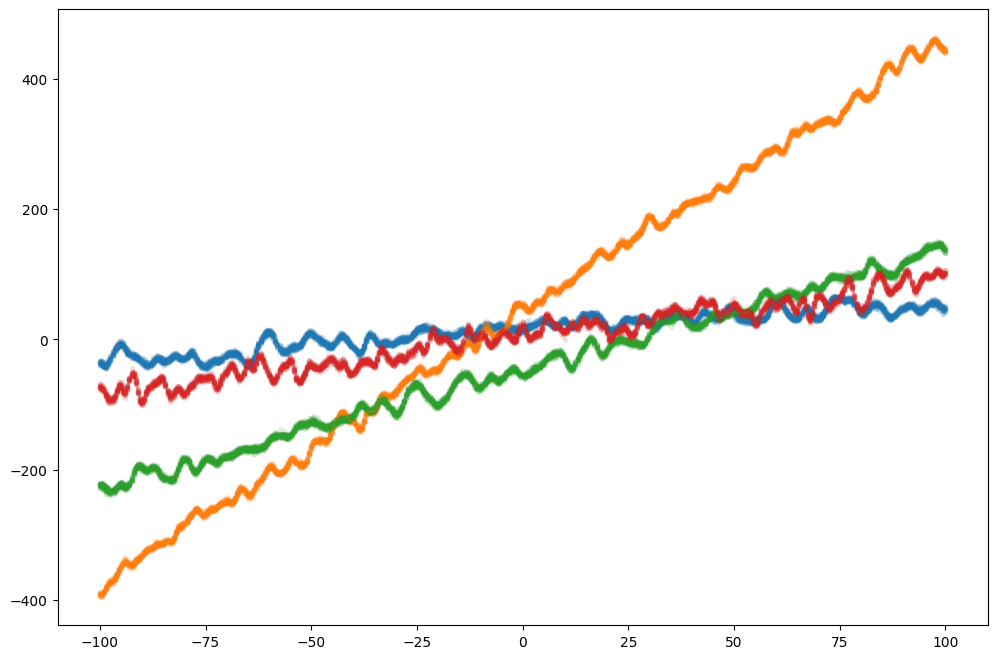

In [16]:
model.plot_mean_processes()
plt.show()

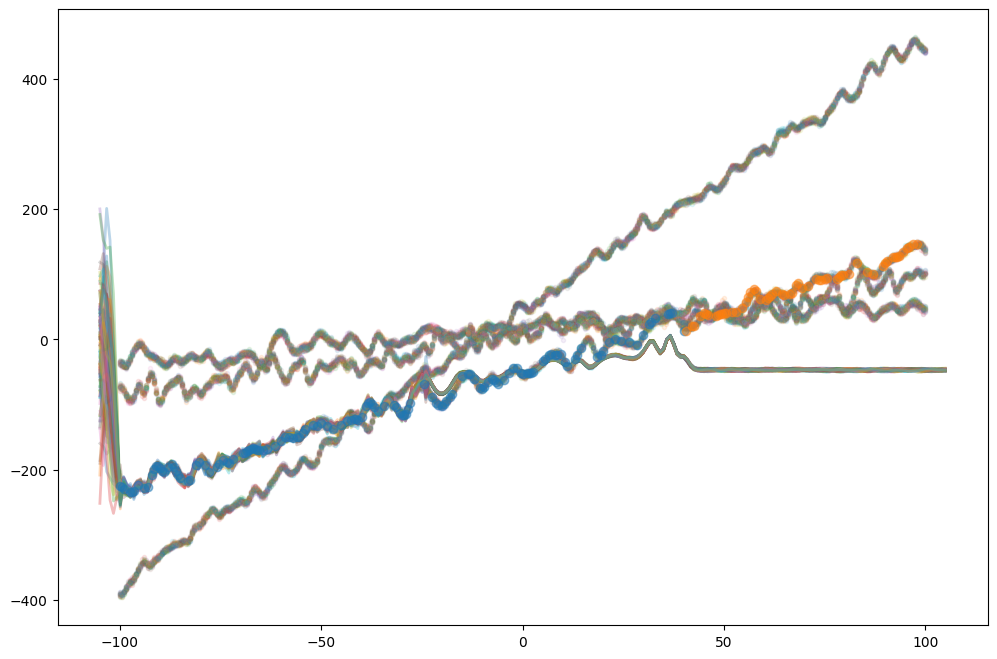

In [17]:
model.plot_predictions(plot_as="samples", task_id=0)
plt.show()

In [18]:
model.sample(16).shape

(40, 16, 250)

In [19]:
model.means_pred.shape, model.covs_pred.shape, model.mixture_pred.shape

((4, 40, 250), (4, 40, 250, 250), (4, 40))

In [20]:
import jax.random as jr
from jax import vmap, Array
import jax.numpy as jnp

from typing import Literal, Optional

from MagmaClustPy.plot import plot_tasks, plot_points, plot_process, plot_samples

In [21]:
def plot_predictions(self, plot_as: Literal["samples", "process"] = "samples", task_id=0,
                     colors="mixture", nb_samples: int = 100, include_train_points=True, key: Array = jr.PRNGKey(42),
                     fig=None, ax=None):

	if colors is None:
		colors = [plt.get_cmap("tab10")(0) for _ in range(self.k)]
	elif colors == "mixture":
		colors = [plt.get_cmap("tab10")(i) for i in range(self.k)]
	else:
		colors = [colors] * self.k

	if fig is None and ax is None:
		fig, ax = plt.subplots(figsize=(12, 8))

	if include_train_points:
		plot_tasks(self.padded_inputs_train, self.padded_outputs_train, point_alpha=0.1, fig=fig, ax=ax)

	# Plot prediction
	if plot_as == "samples":
		samples = self.sample(nb_samples, key=key)  # (N, nb_samples, G)
		plot_samples(self.grid_pred, samples[task_id], alpha=0.3, fig=fig, ax=ax)
	else:
		# Plot K GPs, one per cluster, with alpha proportional to the cluster membership probability
		for k in range(self.k):
			weight = float(self.mixture_pred[k, task_id])
			if weight > 1e-6:
				plot_process(self.grid_pred, self.means_pred[k, task_id], self.covs_pred[k, task_id],
				             ci_alpha=0.3 * weight, curve_alpha=weight, color=colors[k], fig=fig, ax=ax)

	# Plot pred points
	pred_color = plt.get_cmap("tab10")(0)
	plot_points(self.padded_inputs_pred[task_id], self.padded_outputs_pred[task_id], color=pred_color, marker="o",
	            zorder=3, fig=fig, ax=ax)

	# Plot test points
	test_color = plt.get_cmap("tab10")(1)
	plot_points(self.padded_inputs_test[task_id], self.padded_outputs_test[task_id], color=test_color, marker="o",
	            zorder=3, fig=fig, ax=ax)

	return fig, ax

In [24]:
np.asarray(model.mixture_pred.T)

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

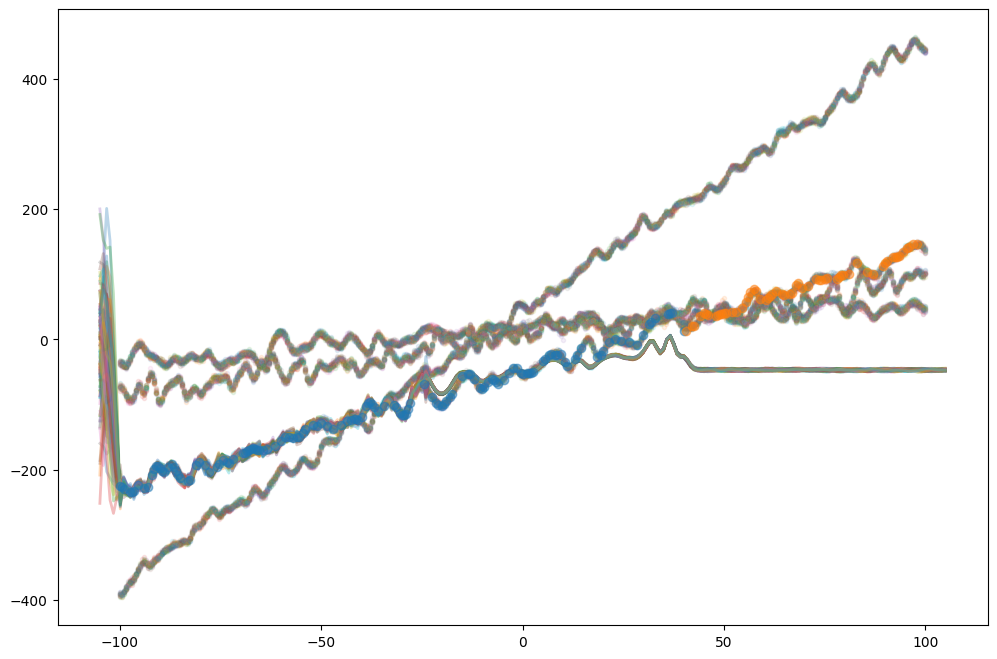

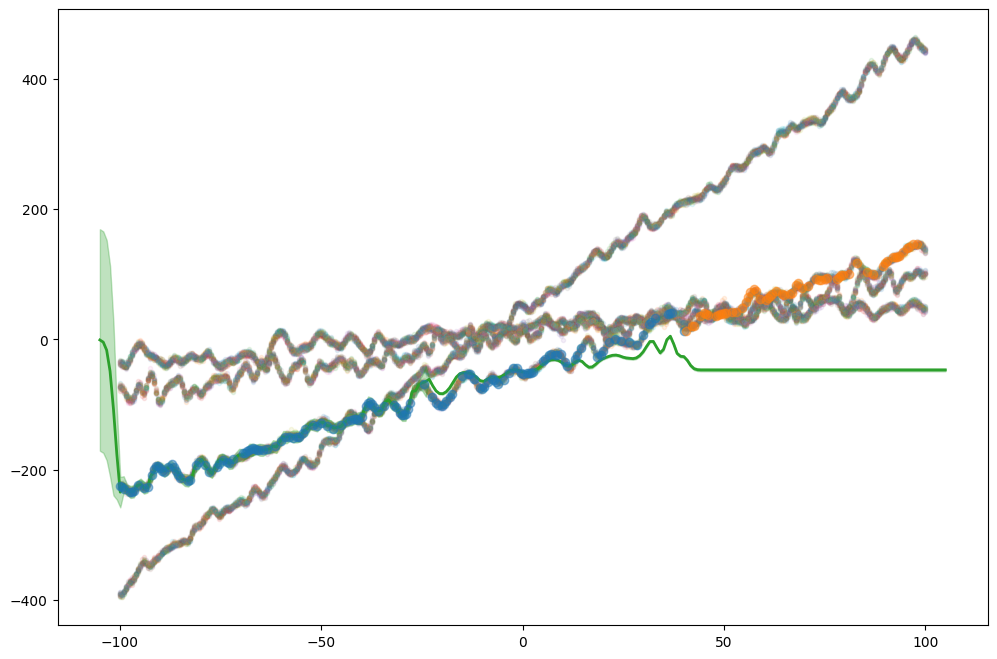

In [22]:
fig, ax = plot_predictions(model, plot_as="samples", task_id=pred_id)
plt.show()

fig, ax = plot_predictions(model, plot_as="process", task_id=pred_id)
plt.show()